<a href="https://colab.research.google.com/github/amrit-pratya/Deep_Learning_projects/blob/main/ANN_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np

In [23]:
df = pd.read_csv("/content/powerplant_data.csv")

In [24]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [25]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity
# PE => produced_energy

In [26]:
df.isnull()

,AT,V,AP,RH,PE
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9563,False,False,False,False,False
9564,False,False,False,False,False
9565,False,False,False,False,False
9566,False,False,False,False,False


In [27]:
X = df.drop('PE',axis=1)
y = df['PE']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [31]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [32]:
# defining the ANN model
class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model = nn.Sequential(

        # 1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        # 2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        # output layer
        nn.Linear(6,1)
    )

  def forward(self,x):
    return self.model(x)

In [33]:
# building the model
import torch.optim as op

model = ANN()

# loss, optimizer
criteria = nn.MSELoss()
optimizer = op.Adam(model.parameters())

In [34]:
# training the model
train_loss = []
val_loss = []

best_val_loss = float('inf')
epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for X_batch, y_batch in train_loader:
    # forward pass
    y_pred = model(X_batch)

    # loss
    loss = criteria(y_pred, y_batch)
    running_loss += loss.item() # loss is a tensor value => python float

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  epoch_train_loss = running_loss / len(train_loader)
  train_loss.append(epoch_train_loss)

  # Validation
  running_val_loss = 0.0

  model.eval()
  with torch.no_grad(): # no grad compute
    for X_batch, y_batch in test_loader:
      y_pred = model(X_batch)
      loss = criteria(y_pred, y_batch)
      running_val_loss += loss.item()
  epoch_val_loss = running_val_loss / len(test_loader)
  val_loss.append(epoch_val_loss)

  print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(), 'best_model.pth')

Epoch: 1/100, Train Loss: 206223.5693, Val Loss: 204554.8932
Epoch: 2/100, Train Loss: 200649.6348, Val Loss: 194471.9758
Epoch: 3/100, Train Loss: 183456.5967, Val Loss: 169815.8753
Epoch: 4/100, Train Loss: 153330.7698, Val Loss: 136869.5348
Epoch: 5/100, Train Loss: 122552.4644, Val Loss: 111358.8043
Epoch: 6/100, Train Loss: 104003.3248, Val Loss: 99407.0932
Epoch: 7/100, Train Loss: 95290.3615, Val Loss: 92620.3900
Epoch: 8/100, Train Loss: 88131.0642, Val Loss: 84215.9788
Epoch: 9/100, Train Loss: 77338.7606, Val Loss: 69033.4473
Epoch: 10/100, Train Loss: 55743.9828, Val Loss: 40641.1459
Epoch: 11/100, Train Loss: 27403.0091, Val Loss: 14687.2243
Epoch: 12/100, Train Loss: 7854.8511, Val Loss: 3154.5495
Epoch: 13/100, Train Loss: 1718.7755, Val Loss: 902.9283
Epoch: 14/100, Train Loss: 622.5927, Val Loss: 472.1957
Epoch: 15/100, Train Loss: 363.2460, Val Loss: 313.4742
Epoch: 16/100, Train Loss: 260.5123, Val Loss: 233.9972
Epoch: 17/100, Train Loss: 198.6306, Val Loss: 186.9454

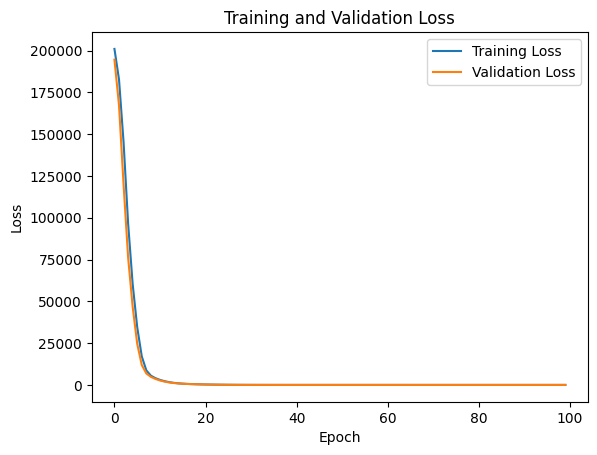

In [21]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({'Training_Loss': train_loss, 'Validation_Loss': val_loss})
plt.plot(loss_df["Training_Loss"], label = "Training Loss")
plt.plot(loss_df["Validation_Loss"], label = "Validation Loss")
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [35]:
# loading the best model
model.load_state_dict(torch.load('/content/best_model.pth'))

# Evaluation
model.eval()
with torch.no_grad():
  training_pred = model(X_train_tensor)
  train_MSE_loss = criteria(training_pred, y_train_tensor)
  print(f"Training MSE Loss: {train_MSE_loss.item():.4f}")
  testing_pred = model(X_test_tensor)
  test_MSE_loss = criteria(testing_pred, y_test_tensor)
  print(f"Testing MSE Loss: {test_MSE_loss.item():.4f}")

Training MSE Loss: 20.5957
Testing MSE Loss: 19.0019


In [36]:
from sklearn.metrics import r2_score

print(f"Training R2 Score: {r2_score(y_train, training_pred.numpy()):.4f}")
print(f"Testing R2 Score: {r2_score(y_test, testing_pred.numpy()):.4f}")

Training R2 Score: 0.9296
Testing R2 Score: 0.9336


In [37]:
pred_df = pd.DataFrame(testing_pred.numpy(), columns=['Predicted'])
Actual_df = pd.DataFrame(y_test.values, columns=['Actual'])
pd.concat([pred_df, Actual_df], axis=1)

,Predicted,Actual
0,435.238831,433.27
1,436.753571,438.16
2,461.689331,458.42
3,476.657471,480.82
4,435.598938,441.41
...,...,...
1909,451.633606,456.70
1910,432.488525,438.04
1911,467.166626,467.80
1912,431.703400,437.14
